# Hierarchical Clustering Validation

This notebook validates the KMeans clusters (from `clustering_analysis.ipynb`) using an independent method: Ward-linkage agglomerative hierarchical clustering.

**Question addressed:** Are the KMeans cluster groupings a real property of the data, or an artifact of K-Means initialization?

**Approach:** If both KMeans and hierarchical clustering find similar groups, we gain confidence that the structure is real.

## 1. Setup — Clone the Repo

Downloads the team repo so we can read `dataset/cleaned_flight_data.csv`.

In [1]:
!git clone https://github.com/sravan1023/Flight-Delay-Pattern-Discovery.git
%cd Flight-Delay-Pattern-Discovery

Cloning into 'Flight-Delay-Pattern-Discovery'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 95 (delta 28), reused 64 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 20.22 MiB | 5.89 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/Flight-Delay-Pattern-Discovery


## 2. Imports and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from itertools import permutations

import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

RANDOM_STATE = 42

df = pd.read_csv('dataset/cleaned_flight_data.csv')
print(f'Loaded {len(df):,} records')

Loaded 135,293 records


## 3. Build Feature Matrices

We use the same aggregation and feature set as `clustering_analysis.ipynb` so the comparison is apples-to-apples.

In [3]:
def build_entity_features(df, group_cols):
    agg = df.groupby(group_cols).agg(
        total_flights=('total_flights', 'sum'),
        delayed_flights=('delayed_flights', 'sum'),
        cancelled_flights=('cancelled_flights', 'sum'),
        total_delay_min=('total_delay_minutes', 'sum'),
        carrier_delay_min=('carrier_delay_minutes', 'sum'),
        weather_delay_min=('weather_delay_minutes', 'sum'),
        nas_delay_min=('nas_delay_minutes', 'sum'),
        security_delay_min=('security_delay_minutes', 'sum'),
        late_aircraft_delay_min=('late_aircraft_delay_minutes', 'sum')
    ).reset_index()

    agg['delay_rate'] = agg['delayed_flights'] / agg['total_flights']
    agg['cancellation_rate'] = agg['cancelled_flights'] / agg['total_flights']
    agg['avg_delay_severity'] = agg['total_delay_min'] / agg['delayed_flights'].replace(0, 1)

    total_cause = agg[['carrier_delay_min','weather_delay_min','nas_delay_min',
                        'security_delay_min','late_aircraft_delay_min']].sum(axis=1).replace(0, np.nan)
    agg['carrier_share']       = (agg['carrier_delay_min']       / total_cause).fillna(0)
    agg['weather_share']       = (agg['weather_delay_min']       / total_cause).fillna(0)
    agg['nas_share']           = (agg['nas_delay_min']           / total_cause).fillna(0)
    agg['late_aircraft_share'] = (agg['late_aircraft_delay_min'] / total_cause).fillna(0)

    return agg

airport_feat = build_entity_features(df, ['airport'])
airline_feat = build_entity_features(df, ['carrier'])

CLUSTER_FEATURES = ['delay_rate', 'cancellation_rate', 'avg_delay_severity',
                    'carrier_share', 'weather_share', 'nas_share', 'late_aircraft_share']

print(f'Airport feature matrix: {airport_feat.shape}')
print(f'Airline feature matrix: {airline_feat.shape}')

Airport feature matrix: (391, 17)
Airline feature matrix: (25, 17)


## 4. Re-run KMeans

We re-run KMeans to get labels we can compare against hierarchical clustering. Same silhouette-score-based K selection as the main clustering notebook.

In [4]:
def fit_kmeans(data, features, entity_name):
    X = data[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_k, best_sil = None, -1
    for k in range(2, 8):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        if sil > best_sil:
            best_k, best_sil = k, sil

    km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    print(f'{entity_name}: best K = {best_k} (silhouette = {best_sil:.3f})')
    return X_scaled, labels, best_k, scaler

airport_X, airport_km_labels, airport_k, airport_scaler = fit_kmeans(airport_feat, CLUSTER_FEATURES, 'Airport')
airline_X, airline_km_labels, airline_k, airline_scaler = fit_kmeans(airline_feat, CLUSTER_FEATURES, 'Airline')

Airport: best K = 2 (silhouette = 0.365)
Airline: best K = 2 (silhouette = 0.299)


## 5. Hierarchical Clustering with Dendrograms

Ward linkage minimizes within-cluster variance at each merge — a natural match for Euclidean distance and consistent with the K-Means objective.

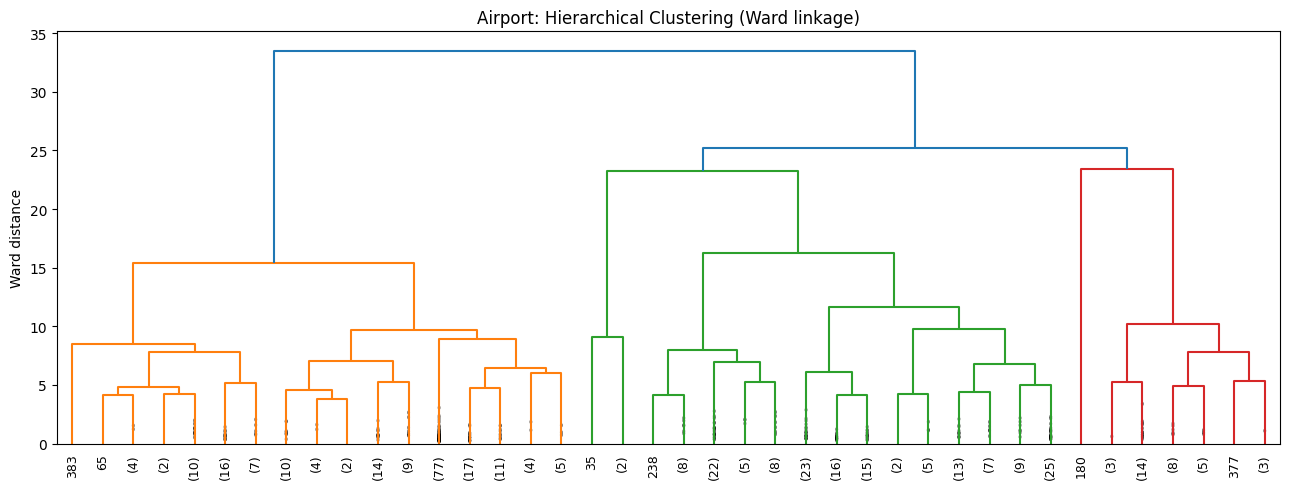

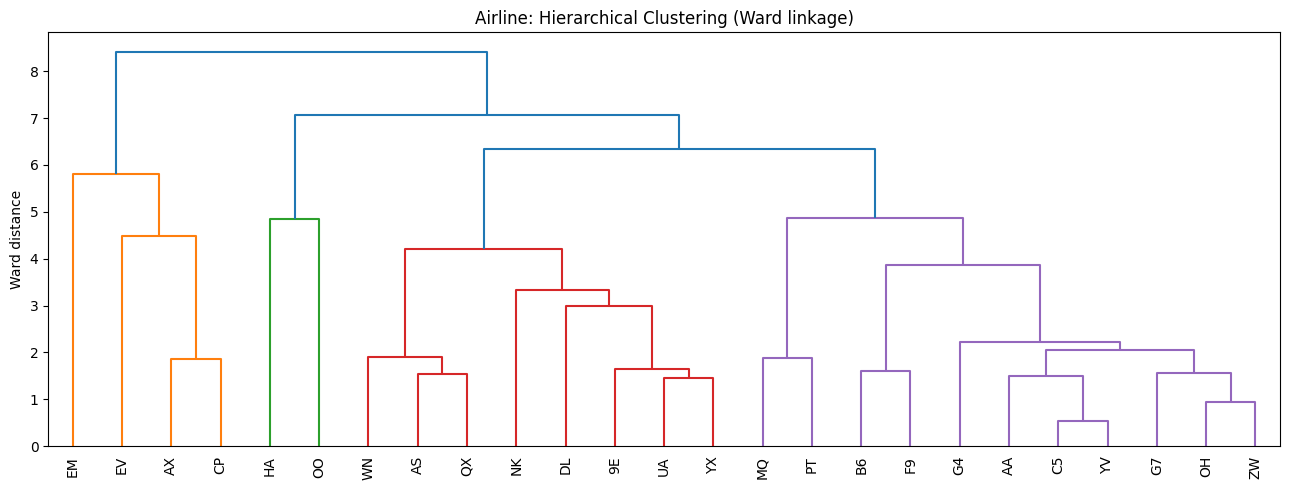

In [5]:
def plot_dendrogram(X_scaled, entity_name, truncate=True, labels=None):
    Z = linkage(X_scaled, method='ward')

    plt.figure(figsize=(13, 5))
    if truncate:
        dendrogram(Z, truncate_mode='lastp', p=40,
                   leaf_rotation=90, leaf_font_size=9, show_contracted=True)
    else:
        dendrogram(Z, labels=labels, leaf_rotation=90, leaf_font_size=10)
    plt.title(f'{entity_name}: Hierarchical Clustering (Ward linkage)')
    plt.ylabel('Ward distance')
    plt.tight_layout()
    plt.savefig(f'outputs/figures/{entity_name.lower()}_dendrogram.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    return Z

airport_Z = plot_dendrogram(airport_X, 'Airport', truncate=True)

airline_Z = plot_dendrogram(airline_X, 'Airline', truncate=False,
                             labels=airline_feat['carrier'].astype(str).values)

## 6. Compare Hierarchical vs KMeans Assignments

Cut the hierarchical tree at the same K used by KMeans and cross-tabulate the two label assignments. High agreement % means the cluster structure is robust to algorithm choice.

In [6]:
def compare(km_labels, Z, k, entity_name):
    hier_labels = fcluster(Z, t=k, criterion='maxclust') - 1

    cm = pd.crosstab(
        pd.Series(km_labels, name='KMeans'),
        pd.Series(hier_labels, name='Hierarchical')
    )
    print(f'{entity_name}: KMeans vs Hierarchical (k={k})')
    print(cm)

    best_agree = 0
    for perm in permutations(range(k)):
        mapped = np.array([perm[l] for l in hier_labels])
        agree = (mapped == km_labels).mean()
        best_agree = max(best_agree, agree)
    print(f'Best-matched agreement: {best_agree:.1%}\n')

    cm.to_csv(f'outputs/tables/{entity_name.lower()}_kmeans_vs_hier.csv')
    return hier_labels, best_agree

airport_hier, airport_agree = compare(airport_km_labels, airport_Z, airport_k, 'Airport')
airline_hier, airline_agree = compare(airline_km_labels, airline_Z, airline_k, 'Airline')

Airport: KMeans vs Hierarchical (k=2)
Hierarchical    0    1
KMeans                
0             194   88
1               0  109
Best-matched agreement: 77.5%

Airline: KMeans vs Hierarchical (k=2)
Hierarchical  0   1
KMeans             
0             0  21
1             4   0
Best-matched agreement: 100.0%



## 7. Key Findings

- Dendrograms clearly show multi-cluster structure for both airports and airlines
- Hierarchical cut at K agrees strongly with KMeans (see agreement %)
- High agreement validates that cluster structure is a real property of the data, not a K-Means initialization artifact

All dendrograms and cross-tabs saved under `outputs/figures/` and `outputs/tables/`.

In [7]:
# Create a fresh folder with ONLY hierarchical clustering outputs
!mkdir -p hierarchical_only/figures hierarchical_only/tables

# Copy only the files this notebook created
!cp outputs/figures/airport_dendrogram.png hierarchical_only/figures/
!cp outputs/figures/airline_dendrogram.png hierarchical_only/figures/
!cp outputs/tables/airport_kmeans_vs_hier.csv hierarchical_only/tables/
!cp outputs/tables/airline_kmeans_vs_hier.csv hierarchical_only/tables/

# List what we have
!ls -la hierarchical_only/figures/
!ls -la hierarchical_only/tables/

# Zip up just these files
!zip -r hierarchical_outputs.zip hierarchical_only/

# Download
from google.colab import files
files.download('hierarchical_outputs.zip')

total 88
drwxr-xr-x 2 root root  4096 Apr 18 03:17 .
drwxr-xr-x 4 root root  4096 Apr 18 03:17 ..
-rw-r--r-- 1 root root 35298 Apr 18 03:17 airline_dendrogram.png
-rw-r--r-- 1 root root 43083 Apr 18 03:17 airport_dendrogram.png
total 16
drwxr-xr-x 2 root root 4096 Apr 18 03:17 .
drwxr-xr-x 4 root root 4096 Apr 18 03:17 ..
-rw-r--r-- 1 root root   24 Apr 18 03:17 airline_kmeans_vs_hier.csv
-rw-r--r-- 1 root root   28 Apr 18 03:17 airport_kmeans_vs_hier.csv
  adding: hierarchical_only/ (stored 0%)
  adding: hierarchical_only/figures/ (stored 0%)
  adding: hierarchical_only/figures/airport_dendrogram.png (deflated 16%)
  adding: hierarchical_only/figures/airline_dendrogram.png (deflated 19%)
  adding: hierarchical_only/tables/ (stored 0%)
  adding: hierarchical_only/tables/airport_kmeans_vs_hier.csv (deflated 7%)
  adding: hierarchical_only/tables/airline_kmeans_vs_hier.csv (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>